# `kamo.trap` — from beams to a BEC density

Beam geometry → trap potential → condensate density, on the *real* potential:
anharmonic, gravity-tilted, evaluated for a specific hyperfine state and field.

1. **Beams** — `Tweezer`, `LightSheet`, `Crossed`: lab-frame polarization and propagation direction, 3D intensity.
2. **The light shift** — state polarizability from UDel-portal matrix elements; why the *field direction* matters.
3. **The trap** — built from the measured 1 kHz radial frequency: sag, principal frequencies, and where the atoms actually escape.
4. **One axis, exactly** — the sinc-DVR bound-state spectrum of the vertical cut.
5. **The density, three ways** — non-interacting, Thomas-Fermi, Gross-Pitaevskii, against the harmonic Gaussian.
6. **What it means for imaging** — the real cloud through `kamo.imaging`.
7. **A crossed trap** — principal axes that are not lab axes.

Conventions: SI throughout; energies quoted as $E/h$ (Hz) or in µK; fields in Gauss.
Lab frame: $x$ is the tweezer (and probe) axis, $z$ is vertical and the quantization axis.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import kamo.constants as kc
from kamo.trap import (Tweezer, LightSheet, Trap, StatePolarizability, NonInteractingSolver,
                       solve, solve_all, comparison_table)
from kamo.trap import plotting as tplt

plt.rcParams.update({"figure.dpi": 110, "legend.fontsize": "small", "legend.frameon": False,
                     "axes.titlesize": "medium", "font.size": 9})
np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings("ignore", message="UDel portal unreachable")   # offline: bundled snapshot

# --- the K-team operating point ---------------------------------------------
STATE = (4, 0, 0.5, 1, -1)        # |F=1, mF=-1>
B_GAUSS, B_DIR = 520.594, (0, 0, 1)
WAIST, WAVELENGTH = 3.0e-6, 1064e-9
F_RADIAL = 1.0e3                  # measured radial trap frequency (Hz)
N_ATOMS = 500

## 1. Beams

A beam is specified by exactly one keyword from each of three groups — colour (`wavelength_m` | `frequency_Hz`),
size (`waist` | `NA` | `rayleigh_range` | `divergence_angle`) and strength (`power` | `peak_intensity`, or neither) —
plus a lab-frame `polarization` (complex 3-vector) and `propagation_direction`. Vectors are normalized and checked:
a polarization with a component along $k$ is rejected. Beams are immutable; `with_power`, `moved_to`, `rotated`
return new ones.

In [2]:
tw = Tweezer(waist=WAIST, wavelength_m=WAVELENGTH, polarization=(0, 1, 1j))   # circular, along +x
sheet = LightSheet(waist=(8e-6, 120e-6), wavelength_m=1064e-9, power=0.2,
                   propagation_direction=(0, 1, 0), polarization=(1, 0, 0),
                   transverse_axis=(0, 0, 1))                                  # thin axis vertical
print(tw)
print(sheet)
print(f"tweezer: zR = {tw.zR*1e6:.1f} um, NA = {tw.NA:.3f}")
print(f"sheet:   zR = ({sheet.rayleigh_range_u*1e6:.0f}, {sheet.rayleigh_range_v*1e6:.0f}) um "
      f"-- the thin axis diverges {(sheet.waist_v/sheet.waist_u)**2:.0f}x faster")

try:
    Tweezer(waist=WAIST, NA=0.2, wavelength_m=WAVELENGTH)
except ValueError as err:
    print("\nover-specified:", err)
try:
    Tweezer(waist=WAIST, wavelength_m=WAVELENGTH, polarization=(1, 0, 0))
except ValueError as err:
    print("not transverse:", str(err)[:90], "...")

Tweezer(w=3 um, lambda=1064.0 nm, P=0 W, k=[1.0, 0.0, 0.0])
LightSheet(w=(8, 120) um, lambda=1064.0 nm, P=0.2 W, k=[0.0, 1.0, 0.0])
tweezer: zR = 26.6 um, NA = 0.113
sheet:   zR = (189, 42518) um -- the thin axis diverges 225x faster

over-specified: size: give exactly one of ['NA', 'divergence_angle', 'rayleigh_range', 'waist']; got ['NA', 'waist'].
not transverse: polarization [1.+0.j 0.+0.j 0.+0.j] is not transverse to propagation_direction [1. 0. 0.]: ...


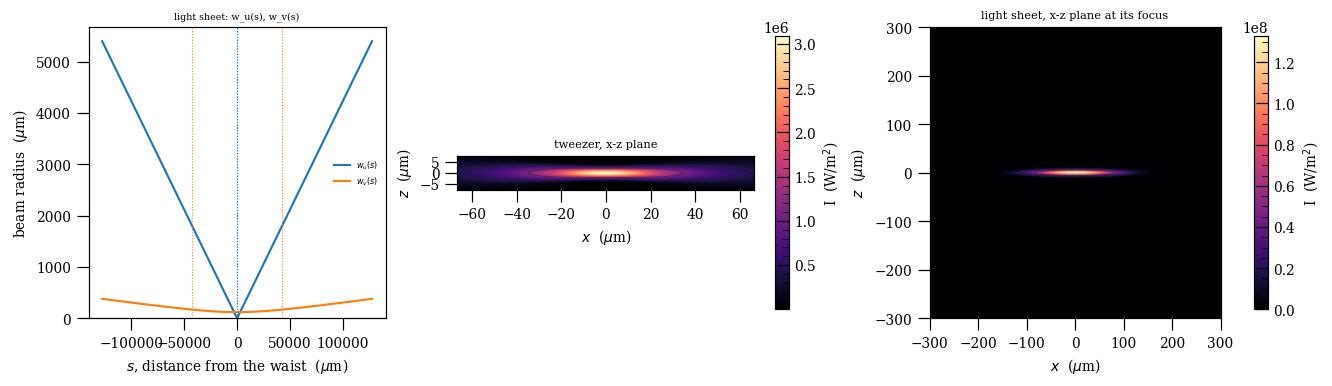

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), layout="constrained")
tplt.plot_beam_profile(sheet, ax=axes[0], title="light sheet: w_u(s), w_v(s)")
tplt.plot_plane_cut(tw.with_power(43.65e-6), normal=(0, 1, 0), ax=axes[1], title="tweezer, x-z plane")
tplt.plot_plane_cut(sheet, normal=(0, 1, 0), ax=axes[2], title="light sheet, x-z plane at its focus")
plt.show()

## 2. The light shift, and why the field direction matters

The AC Stark shift is $U = -\alpha I / (2 c \epsilon_0)$ with
$\alpha = \alpha_s - \beta\,\frac{m_F}{2F}\alpha_v + \gamma\,\frac{3m_F^2 - F(F+1)}{F(2F-1)}\alpha_t$.
The two geometry factors are computed **in the lab frame** from the beam polarization $\hat\epsilon$ and the
quantization axis $\hat B$: $\beta = \mathrm{Im}(\hat\epsilon\times\hat\epsilon^*)\cdot\hat B$ (circularity) and
$\gamma = (3|\hat\epsilon\cdot\hat B|^2 - 1)/2$ (alignment).

The matrix elements come from the UDel atomic-physics portal (measured D-line elements, with ARC filling in the
rest) plus the K⁺ core; every `StatePolarizability` reports where its numbers came from.

In [4]:
sp = StatePolarizability(STATE)                 # portal + ARC fill-in, K+ core, cached module-wide
a_s, a_v, a_t = sp.components_au(WAVELENGTH)
print(f"4S1/2 |1,-1> at 1064 nm: alpha_s = {a_s:.3f} a.u., alpha_v = {a_v:.3f} a.u. (alpha_t = 0 for j = 1/2)")
print(f"portal uncertainty on alpha_s: +- {sp.uncertainty_au(WAVELENGTH):.3f} a.u.")
print(sp.describe(WAVELENGTH))

# the same circular beam (0, 1, i) along x, two field directions
for bhat, label in (((0, 0, 1), "B along z (perpendicular to the beam)"), ((1, 0, 0), "B along x (along the beam)")):
    a_m = sp.alpha_au(WAVELENGTH, tw.polarization, bhat)
    a_p = sp.for_state((4, 0, 0.5, 1, +1)).alpha_au(WAVELENGTH, tw.polarization, bhat)
    print(f"{label:42s} alpha(mF=-1) = {a_m:8.3f}  alpha(mF=+1) = {a_p:8.3f} a.u.  "
          f"-> differential {a_p - a_m:+.3f} a.u.")

4S1/2 |1,-1> at 1064 nm: alpha_s = 599.301 a.u., alpha_v = 2.631 a.u. (alpha_t = 0 for j = 1/2)
portal uncertainty on alpha_s: +- 0.453 a.u.
polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
B along z (perpendicular to the beam)      alpha(mF=-1) =  599.301  alpha(mF=+1) =  599.301 a.u.  -> differential +0.000 a.u.
B along x (along the beam)                 alpha(mF=-1) =  597.985  alpha(mF=+1) =  600.616 a.u.  -> differential +2.631 a.u.


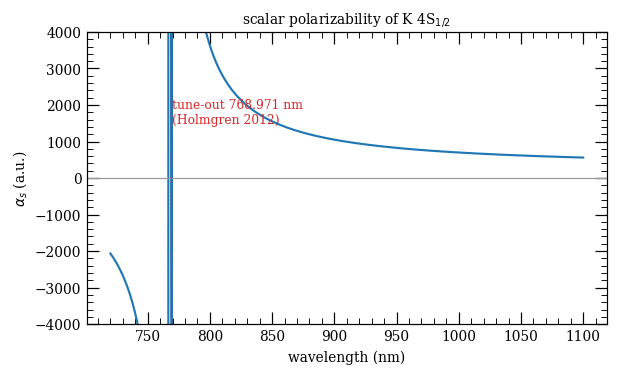

In [5]:
lam = np.linspace(720e-9, 1100e-9, 600)
alpha = np.array([sp.components_au(L)[0] for L in lam])
zero = lam[np.argmin(np.abs(alpha[(lam > 767e-9) & (lam < 770e-9)]))]

fig, ax = plt.subplots(figsize=(5.5, 3.3), layout="constrained")
ax.plot(lam * 1e9, alpha, lw=1.4)
ax.axhline(0, color="0.6", lw=0.8)
ax.axvline(768.9712, color="tab:red", ls=":", lw=0.9)
ax.annotate("tune-out 768.971 nm\n(Holmgren 2012)", (769.5, 1500), fontsize=8, color="tab:red")
ax.set_ylim(-4000, 4000)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel(r"$\alpha_s$ (a.u.)")
ax.set_title("scalar polarizability of K 4S$_{1/2}$")
plt.show()

## 3. The trap

`Trap(beams, state, B)` evaluates the potential, each beam with its own polarizability, plus gravity.
Nothing here needs a trap depth or a polarizability as input: the trap is specified by its geometry and then
scaled to the **measured** 1 kHz radial frequency. Everything else — the sagged minimum, the principal
frequencies (numerical Hessian), the escape depth — follows from $U(\mathbf r)$.

In [6]:
trap = Trap(tw, state=STATE, B_gauss=B_GAUSS, B_direction=B_DIR).rescaled_to_frequency(F_RADIAL)
print(trap.summary())
print(f"\npower for {F_RADIAL/1e3:.0f} kHz radial: {trap.field.power*1e6:.2f} uW")
print(f"principal frequencies: {trap.frequencies_Hz} Hz along\n{trap.principal_axes}")
print(f"sag: {trap.sag_along_gravity*1e9:.1f} nm  (harmonic estimate g/w^2 = "
      f"{9.80665/(2*np.pi*trap.frequencies_Hz[1])**2*1e9:.1f} nm)")

Trap: 1 beam(s), state (4, 0, 0.5, 1.0, -1.0), B = 520.6 G along [0.0, 0.0, 1.0], gravity on
  Tweezer(w=3 um, lambda=1064.0 nm, P=4.425e-05 W, k=[1.0, 0.0, 0.0]): alpha = 599.301 a.u.
  polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
  minimum at (+0.0000, +0.0000, -0.2484) um, U/h = -8.9114 kHz
  gravitational sag 248.41 nm
  principal frequencies 1000.000, 986.192, 79.279 Hz
  escape depth 4.4283 kHz = 0.2125 uK
  escape saddle at (-28.679, +0.000, -3.121) um

power for 1 kHz radial: 44.25 uW
principal frequencies: [1000.      986.1924   79.2788] Hz along
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
sag: 248.4 nm  (harmonic estimate g/w^2 = 255.4 nm)


### Where the atoms leave

A 1D vertical cut through the focus has its escape lip straight below the trap — that is what a 1D model
(or the `gaussian_well` notebook) reports. In 3D the first-order saddle is elsewhere: about a Rayleigh range
*along the beam*, where the beam is weaker and wider, the gravity lip is lower. `trap_depth_J` finds that saddle
by Newton on $\nabla U = 0$; `escape_barrier_J(direction)` gives the barrier along any single ray.

barrier straight down:        4983.4 Hz  = 0.239 uK   (the 1D vertical cut)
3D escape depth (saddle):     4428.3 Hz  = 0.213 uK
saddle at (-28.7, +0.0, -3.12) um -- 1.08 zR along the beam, 11% below the vertical-cut number


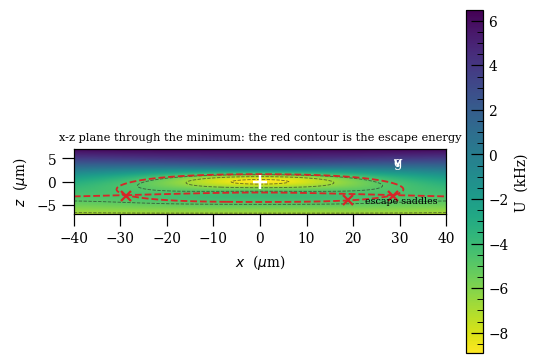

In [7]:
down = trap.escape_barrier_J([0, 0, -1])
s = trap.escape_saddle
print(f"barrier straight down:      {down/kc.h:8.1f} Hz  = {down/kc.kB*1e6:.3f} uK   (the 1D vertical cut)")
print(f"3D escape depth (saddle):   {trap.depth_Hz:8.1f} Hz  = {trap.depth_uK:.3f} uK")
print(f"saddle at ({s[0]*1e6:+.1f}, {s[1]*1e6:+.1f}, {s[2]*1e6:+.2f}) um -- {abs(s[0])/tw.zR:.2f} zR along the beam,"
      f" {100*(1 - trap.depth_J/down):.0f}% below the vertical-cut number")

fig, ax = tplt.plot_plane_cut(trap, normal=(0, 1, 0), half_width=(40e-6, 7e-6), n=(321, 121),
                              units="kHz", title="x-z plane through the minimum: the red contour is the escape energy")
ax.plot([s[0]*1e6, -s[0]*1e6], [s[2]*1e6, s[2]*1e6], "x", color="tab:red", ms=7, mew=1.5, label="escape saddles")
ax.legend(loc="lower right", fontsize="x-small")
plt.show()

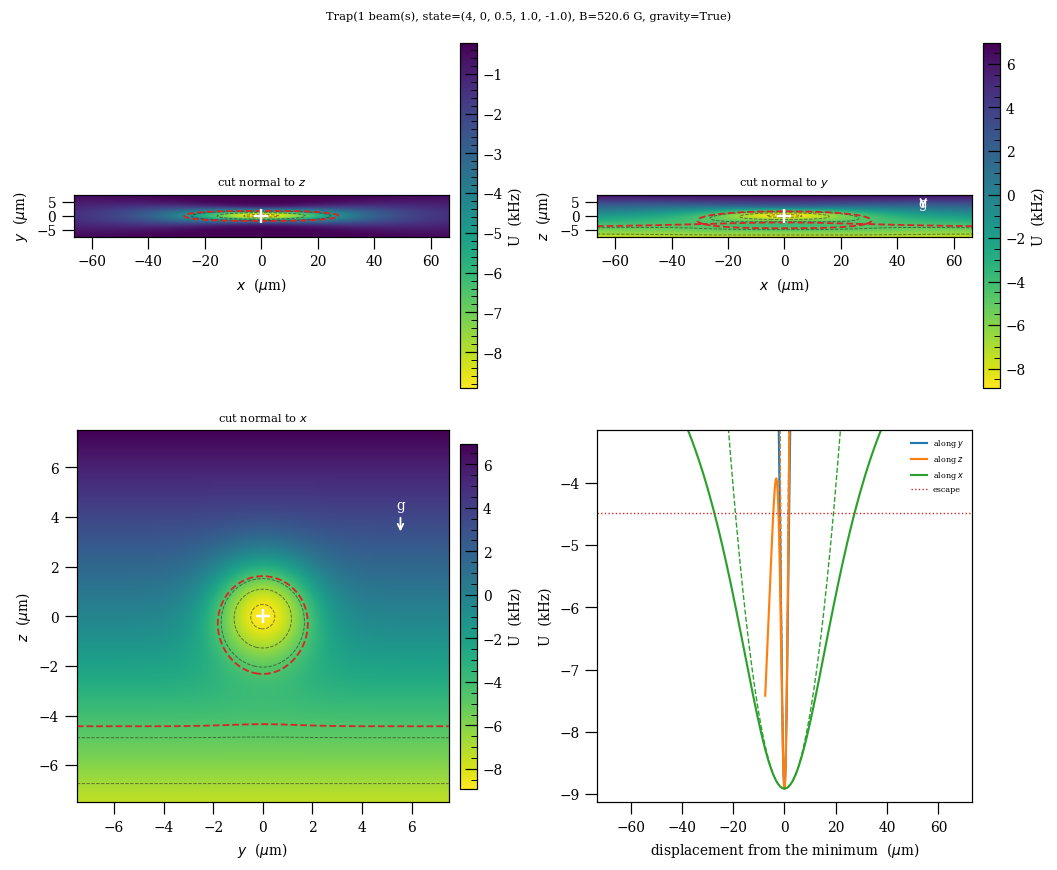

In [8]:
fig, axes = tplt.plot_trap_summary(trap, units="kHz")
plt.show()

## 4. One axis, exactly

`NonInteractingSolver.axis_spectra()` solves the 1D Schrödinger equation along each principal axis with a
sinc-DVR (spectrally accurate on a uniform grid). It reports the bound-state count, the level spacings against the
harmonic $\hbar\omega$, and — with gravity — the escape lip. The vertical radial cut is the interesting one.
The axial cut is a different well: its Lorentzian profile holds hundreds of states, and the top ones are limited by the finite box (the summary says how many were left unresolved) rather than by the trap.

In [9]:
ni = NonInteractingSolver(trap)
specs = ni.axis_spectra()
names = ["y (horizontal radial)", "z (vertical radial)", "x (axial)"]
for name, spec in zip(names, specs):
    print(f"--- {name}")
    print(spec.summary())

--- y (horizontal radial)
AxisSpectrum: 14 bound state(s)
  minimum      u = +0.0000 um,  V_min/h = -8.9114 kHz
  escape       over the box edge,  E_escape/h = -0.2379 kHz,  usable depth/h = 8.6735 kHz
  curvature    f = 1000.000 Hz at the minimum
  ground state (E_0 - V_min)/h = 489.167 Hz,  anharmonicity -1.083% of hbar omega
  spacings / hbar omega: 0.9561, 0.9110, 0.8644, 0.8162, 0.7660, ...
  sigma = 0.3683 um  (harmonic 0.3601 um)
--- z (vertical radial)
AxisSpectrum: 6 bound state(s)
  minimum      u = +0.0000 um,  V_min/h = -8.9114 kHz
  escape       lip at u = -3.201 um,  E_escape/h = -3.9280 kHz,  usable depth/h = 4.9834 kHz
  curvature    f = 986.192 Hz at the minimum
  ground state (E_0 - V_min)/h = 481.366 Hz,  anharmonicity -1.189% of hbar omega
  spacings / hbar omega: 0.9494, 0.8950, 0.8348, 0.7647, 0.6732
  sigma = 0.3719 um  (harmonic 0.3627 um)
--- x (axial)
AxisSpectrum: 391 bound state(s), 34 unresolved at the box edge
  minimum      u = +0.0000 um,  V_min/h = -8.9

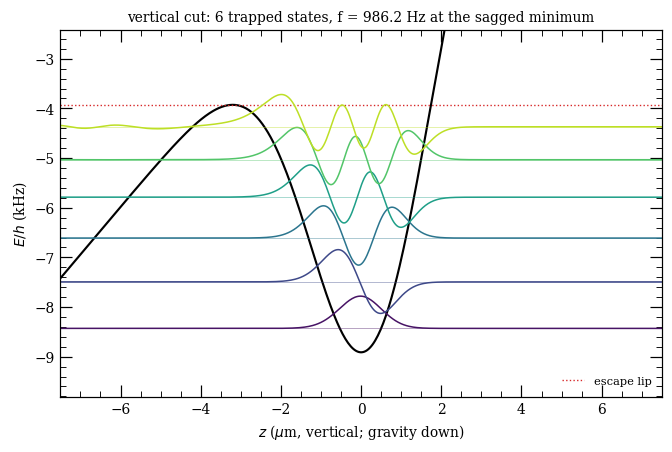

In [10]:
spec = specs[1]                                                   # the vertical cut
u_um, V_kHz, E_kHz = spec.u * 1e6, spec.V / kc.h / 1e3, spec.bound_energies / kc.h / 1e3
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot(u_um, V_kHz, "k", lw=1.4)
ax.axhline(spec.E_escape / kc.h / 1e3, color="tab:red", ls=":", lw=0.9, label="escape lip")
spacing = np.mean(np.diff(E_kHz))
cols = plt.cm.viridis(np.linspace(0.05, 0.9, spec.n_bound))
for n in range(spec.n_bound):
    psi = spec.psi[:, n]
    ax.plot(u_um, E_kHz[n] + 0.8 * spacing * psi / np.abs(psi).max(), color=cols[n], lw=1)
    ax.axhline(E_kHz[n], color=cols[n], lw=0.5, alpha=0.5)
ax.set_xlim(-2.5 * WAIST * 1e6, 2.5 * WAIST * 1e6)
ax.set_ylim(1.1 * V_kHz.min(), spec.E_escape / kc.h / 1e3 + 1.5)
ax.set_xlabel(r"$z$ ($\mu$m, vertical; gravity down)"); ax.set_ylabel(r"$E/h$ (kHz)")
ax.set_title(f"vertical cut: {spec.n_bound} trapped states, f = {spec.frequency_Hz:.1f} Hz at the sagged minimum")
ax.legend(loc="lower right")
plt.show()

## 5. The density, three ways

`solve(trap, N, mode)` returns a `TrapCloud` from any of the three solvers, all on the real potential:

* **noninteracting** — the 3D ground state (tensor-product sinc-DVR Hamiltonian, LOBPCG);
* **thomas-fermi** — $n = \max(0, (\mu - V)/g)$ with $\mu$ from the atom number;
* **gp** — the Gross-Pitaevskii ground state (imaginary time, then a self-consistent LOBPCG polish to a
  residual below $10^{-8}$).

The scattering length for $|1,-1\rangle$ at this field comes from `kamo.scattering`.
The harmonic Gaussian of `GaussianVariationalCloud` — what kamo used before — is the reference row.

In [11]:
clouds = solve_all(trap, N_ATOMS, options={"gp": dict(points_per_scale=3.0)})
clouds["harmonic Gaussian"] = clouds["gp"].harmonic_reference()
print(f"a = {clouds['gp'].a_scattering / kc.a0:+.2f} a0,  Thomas-Fermi valid here: {clouds['gp'].thomas_fermi_valid}\n")
print(comparison_table(clouds, axes=trap.principal_axes))
print("\n" + clouds["gp"].summary())

a = +11.55 a0,  Thomas-Fermi valid here: False

mode                  (mu-Vmin)/h Hz    n0 cm^-3  column cm^-2          sigma x,y,z (um)
noninteracting                999.44   1.673e+14     5.639e+10   1.3251  0.3721  0.3758
thomas-fermi                  427.06   2.144e+14     1.724e+11   2.3010  0.1802  0.1830
gp                           1091.36   1.106e+14     5.323e+10   1.7546  0.3814  0.3855
harmonic Gaussian            1136.34   1.360e+14     5.806e+10   1.7028  0.3689  0.3716

TrapCloud (gp): N = 500, a = +11.545 a0
  grid TrapGrid(126x50x50, +-(14.2, 3.07, 3.09) um), normalization error +4.4e-16
  (mu - V_min)/h = 1091.360 Hz, (E/N - V_min)/h = 1049.207 Hz
  centroid (+0.0000, -0.0000, -0.2861) um, sigma (1.7546, 0.3814, 0.3855) um
  n0 = 1.1064e+14 cm^-3, peak column 5.3232e+10 cm^-2
  healing length 0.7672 um, Thomas-Fermi NOT valid here


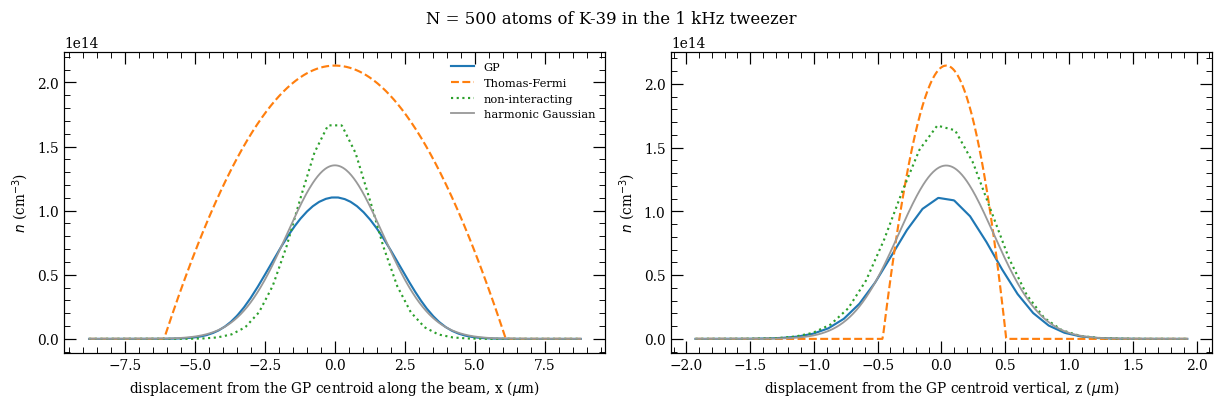

In [12]:
gp, tf, ni_cloud, var = clouds["gp"], clouds["thomas-fermi"], clouds["noninteracting"], clouds["harmonic Gaussian"]
c = gp.centroid
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
for ax, (axis, label) in zip(axes, ((0, "along the beam, x"), (2, "vertical, z"))):
    s = np.linspace(-1, 1, 601) * (5.0 * gp.sigma[axis])
    r = [np.full_like(s, c[0]), np.full_like(s, c[1]), np.full_like(s, c[2])]
    r[axis] = c[axis] + s
    for cl, name, ls in ((gp, "GP", "-"), (tf, "Thomas-Fermi", "--"), (ni_cloud, "non-interacting", ":")):
        ax.plot(s * 1e6, cl.density(*r) * 1e-6, ls, label=name, lw=1.4)
    # the harmonic Gaussian is centred on the trap minimum and knows nothing about the sag or the anharmonicity
    R = trap.principal_axes
    m = trap.minimum_position
    p = [R[k] @ np.stack([r[0] - m[0], r[1] - m[1], r[2] - m[2]]) for k in range(3)]
    ax.plot(s * 1e6, var.density(*p) * 1e-6, "-", color="0.6", lw=1.2, label="harmonic Gaussian")
    ax.set_xlabel(f"displacement from the GP centroid {label} " + r"($\mu$m)")
    ax.set_ylabel(r"$n$ (cm$^{-3}$)")
axes[0].legend()
fig.suptitle(f"N = {N_ATOMS} atoms of K-39 in the 1 kHz tweezer")
plt.show()

## 6. What it means for imaging

The imaging phase is linear in the column density, so the difference between the real condensate and the harmonic
Gaussian is a direct systematic in any phase-contrast calculation built on the latter. `GriddedMixture` puts any
`TrapCloud` through `kamo.imaging`'s propagator on the same footing as the Gaussian `UniformMixture`
(and stays on its array-generic GPU path).

peak density:        GP / harmonic Gaussian = 0.813
peak column density: GP / harmonic Gaussian = 0.917


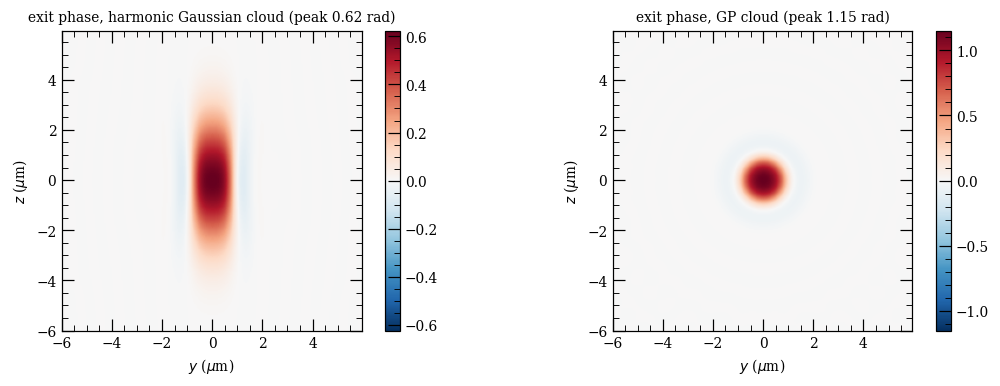

In [13]:
from kamo.imaging import Propagator, UniformMixture, TwoLevelResponse
from kamo.trap.imaging_bridge import GriddedMixture

R2 = trap.principal_axes ** 2
w_lab = np.sqrt(R2.T @ var.widths ** 2)
print(f"peak density:        GP / harmonic Gaussian = {gp.peak_density / var.peak_density:.3f}")
print(f"peak column density: GP / harmonic Gaussian = "
      f"{gp.peak_column_density / (var.N / (np.pi * w_lab[1] * w_lab[2])):.3f}")

response = TwoLevelResponse(766.7e-9, 6.0309e6)            # D2 line, portal linewidth
species = [(1.0, -18.28)]                                   # one component, 18 half-linewidths red: a phase object
prop = Propagator.for_cloud(response, var, n_grid=256, L_box=12e-6, n_slices=60)
psi_gauss = prop.propagate(UniformMixture(var, response, species), saturate=False).psi_exit
psi_gp = prop.propagate(GriddedMixture.for_propagator(prop, gp, response, species), saturate=False).psi_exit

ax_um = prop.grid.axis * 1e6
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), layout="constrained")
for ax, psi, name in zip(axes, (psi_gauss, psi_gp), ("harmonic Gaussian", "GP")):
    im = ax.imshow(np.angle(psi).T, extent=[ax_um[0], ax_um[-1]] * 2, origin="lower", cmap="RdBu_r",
                   vmin=-np.abs(np.angle(psi)).max(), vmax=np.abs(np.angle(psi)).max())
    ax.set_title(f"exit phase, {name} cloud (peak {np.abs(np.angle(psi)).max():.2f} rad)")
    ax.set_xlabel(r"$y$ ($\mu$m)"); ax.set_ylabel(r"$z$ ($\mu$m)")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 7. A crossed trap

Two tweezers at ±45° in the horizontal plane, at different wavelengths so their intensities add incoherently
(`Crossed` warns if two beams could interfere). The principal axes of the Hessian are not lab axes; each beam
carries its own polarizability.

Trap: 2 beam(s), state (4, 0, 0.5, 1.0, -1.0), B = 520.6 G along [0.0, 0.0, 1.0], gravity on
  Tweezer(w=4 um, lambda=1064.0 nm, P=0.02 W, k=[0.7071, 0.7071, 0.0], label='1064'): alpha = 599.301 a.u.
  Tweezer(w=6 um, lambda=1070.0 nm, P=0.06 W, k=[0.7071, -0.7071, 0.0], label='1070'): alpha = 592.179 a.u.
  polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
  minimum at (+0.0000, +0.0000, -0.0011) um, U/h = -5180.3482 kHz
  gravitational sag 1.08 nm
  principal frequencies 15160.869, 12045.889, 9241.480 Hz
  escape depth 5145.9452 kHz = 246.9664 uK
  escape saddle at (-280.899, -280.899, -23.951) um

principal axes (rows):
 [[ 0.      0.      1.    ]
 [-0.7071  0.7071  0.    ]
 [-0.7071 -0.7071 -0.    ]]


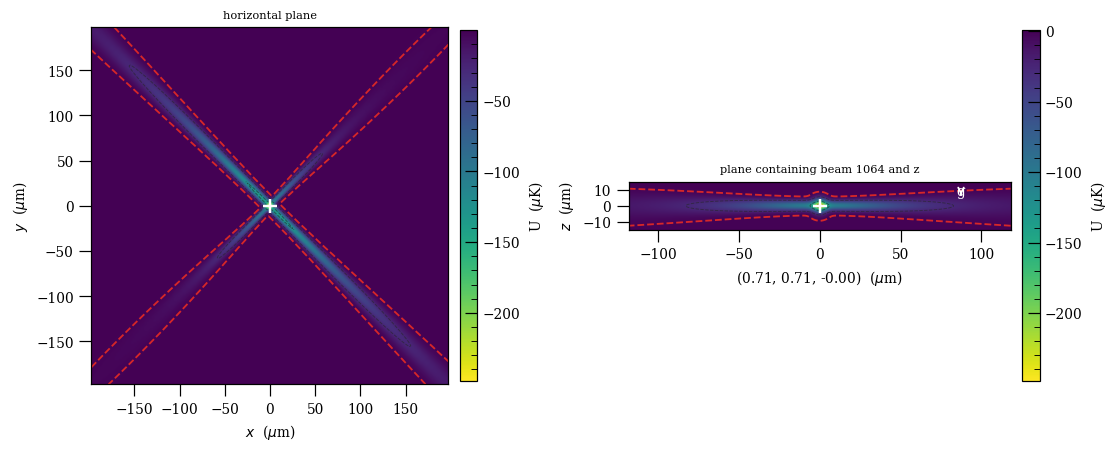

TrapCloud (gp): N = 2000, a = +11.545 a0
  grid TrapGrid(154x154x110, +-(1.14, 1.14, 0.832) um), normalization error +0.0e+00
  (mu - V_min)/h = 44923.754 Hz, (E/N - V_min)/h = 34755.219 Hz
  centroid (+0.0000, -0.0000, -0.0011) um, sigma (0.1745, 0.1745, 0.1281) um
  n0 = 2.0912e+16 cm^-3, peak column 1.1434e+12 cm^-2
  healing length 0.0558 um, Thomas-Fermi NOT valid here


In [14]:
a = Tweezer(waist=4e-6, wavelength_m=1064e-9, power=20e-3, propagation_direction=(1, 1, 0),
            polarization=(0, 0, 1), label="1064")
b = Tweezer(waist=6e-6, wavelength_m=1070e-9, power=60e-3, propagation_direction=(1, -1, 0),
            polarization=(0, 0, 1), label="1070")
crossed = Trap(a + b, state=STATE, B_gauss=B_GAUSS, B_direction=B_DIR)
print(crossed.summary())
print("\nprincipal axes (rows):\n", crossed.principal_axes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
tplt.plot_plane_cut(crossed, normal=(0, 0, 1), ax=axes[0], units="uK", title="horizontal plane")
tplt.plot_plane_cut(crossed, normal=(1, -1, 0), ax=axes[1], units="uK", title="plane containing beam 1064 and z")
plt.show()

cross_cloud = solve(crossed, 2000, "gp", points_per_scale=3.0)
print(cross_cloud.summary())

## Approximations, and what is not here yet

* Fundamental Gaussian modes, paraxial: no Gouy phase, no wavefront curvature, no longitudinal field
  (a NA-0.5 tweezer's polarization is ~10% non-transverse). Beams add incoherently.
* Second-order AC Stark shift only; the field is uniform (its direction is the quantization axis, it exerts no force),
  and $|F, m_F\rangle$ is the right basis only while the Zeeman splitting dominates the vector light shift.
* Zero temperature. Finite $T$ is the next step: `TrapCloud` already carries `T_K`, `condensate_fraction`
  and `density_thermal`; the Thomas-Fermi and GP solvers take a `V_extra` (for $2 g n_{\rm th}$ in a
  Popov / Hartree-Fock loop); the non-interacting solver keeps its excited states for a Boltzmann sum.